<a href="https://colab.research.google.com/github/leticiasdrummond/Modelos-Base/blob/main/USINA_ECONOMIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade Avaliativa II**

## Economic Evaluation of Power Generation Projects

This section addresses the economic evaluation of two power generation investment alternatives: a natural gas plant (480MW) and a solar plant (25MW). The objective is to calculate the minimum selling price of electricity, the Levelized Cost of Electricity (LCOE), and the minimum selling price for capacity for the natural gas plant.

# **Atividade Intividual de Economia de Energia II**

- Letícia Sampaio Drummond Valladares RA:298985
- Professor: Arnaldo Walter

Junho de 2026

---

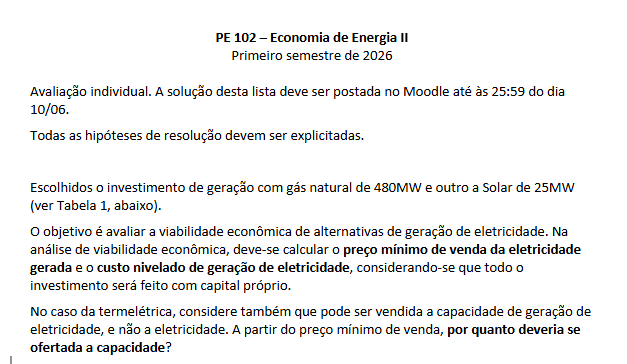

### 1. Parameter Definition

First, let's define all the input parameters provided in the problem description, including the chosen discount rate. The problem states that the discount rate should be justified; for private investments in the energy sector, rates typically range from 8% to 15% depending on risk. Given the absence of specific risk profiles, a **10%** discount rate is chosen as a reasonable and commonly used benchmark for projects with moderate risk, balancing investor returns and project viability.

**Assumptions:**
*   **Capacity Factor (FC anual %)**: Interpreted as the annual capacity factor (or load factor) for both technologies, representing the actual output over a period as a percentage of the maximum possible output.
*   **Monetary Units**: All calculations will be performed in **USD**, as all provided cost data is in US$. If an exchange rate were provided, conversions for BRL-specific thresholds (like the IR profit threshold) would be applied.
*   **Hours per Year**: Assumed to be 8760 hours (24 hours * 365 days).
*   **Inflation**: Not specified, so all costs and revenues are assumed to be in real terms (constant dollars), consistent with a real discount rate.

In [ ]:
# @title
import pandas as pd

# --- Common Parameters ---
discount_rate = 0.08 # 10% chosen as a reasonable rate for private energy investments
hours_per_year = 8760

# --- Natural Gas Plant Parameters ---
capacity_gas_mw = 480 # MW
overnight_costs_gas_usd_per_kw = 739 # US$/kW
efficiency_gas_percent = 0.34 # 34% (electrical efficiency)
o_m_gas_usd_per_mwh = 16.71 # US$/MWh
capacity_factor_gas_percent = 0.30 # 30% (interpreted as annual capacity factor)
fuel_cost_gas_usd_per_gj = 5.0 # US$/GJ
construction_time_gas_years = 3 # Years
operational_life_gas_years = 30 # Years

# Construction cost fractions for Natural Gas (years before operation start: -2, -1, 0)
# Year 0 here means the year of commissioning, not end of year 0.
# The problem states '-2', '-1', '0' as years before the start of operation. So, -2 is 2 years before, -1 is 1 year before, 0 is the start year.
construction_fractions_gas = {
    'Year -2': 0.17,
    'Year -1': 0.49,
    'Year 0': 0.34 # Year of commissioning / start of operation
}

# --- Solar Plant Parameters ---
capacity_solar_mw = 25 # MW
overnight_costs_solar_usd_per_kw = 1197 # US$/kW
o_m_solar_usd_per_mwh = 6.48 # US$/MWh
capacity_factor_solar_percent = 0.31 # 31% (interpreted as annual capacity factor)
construction_time_solar_years = 2 # Years
operational_life_solar_years = 25 # Years

# Construction cost fractions for Solar (years before operation start: -1, 0)
construction_fractions_solar = {
    'Year -1': 0.40,
    'Year 0': 0.60 # Year of commissioning / start of operation
}

# --- Tax and Charges Parameters (Common for both, assuming USD equivalent for BRL thresholds) ---
tax_confins = 0.0760 # 7.60% on gross revenue
tax_pis = 0.0165 # 1.65% on gross revenue
tax_tfsee = 0.0050 # 0.50% on gross revenue
tax_csll = 0.090 # 9.0% on real profit
tax_ir_base = 0.150 # 15.0% on real profit
tax_ir_additional = 0.100 # 10.0% additional on profit exceeding threshold
ir_profit_threshold_monthly_usd = 3508.59  # US$ por limite lucro
print("Parameters defined successfully.")

### 2. Investment Cost Calculation

This section calculates the total investment cost for both the natural gas and solar power plants. The calculation will consider the overnight costs, the capacity, and the construction schedule, applying the discount rate to account for the time value of money during the construction phase. Since the problem specifies "overnight costs" and then lists construction fractions across multiple years, it implies a need to discount these construction expenditures back to a common point (e.g., the start of construction or the commercial operation date) to get a time-valued total investment.

We will calculate the present value of all construction expenditures at the Commercial Operation Date (COD), which is 'Year 0' in the provided construction fractions. This approach is consistent with how project finance often evaluates total capital expenditure.

First, let's calculate the total overnight cost (total capital expenditure before considering construction period financing) for each plant:

In [ ]:
# @title
# Total Overnight Costs
total_overnight_costs_gas = capacity_gas_mw * 1000 * overnight_costs_gas_usd_per_kw # MW to kW, then to total USD
total_overnight_costs_solar = capacity_solar_mw * 1000 * overnight_costs_solar_usd_per_kw # MW to kW, then to total USD

print(f"Total Overnight Costs for Natural Gas Plant: US$ {total_overnight_costs_gas:,.2f}")
print(f"Total Overnight Costs for Solar Plant: US$ {total_overnight_costs_solar:,.2f}")

# Now, calculate the total investment cost including construction period financing (time value of money)
# We discount/compound all expenditures to the Commercial Operation Date (COD), which is 'Year 0'.

# Natural Gas Plant
# Construction years are -2, -1, 0. 'Year 0' is the COD. '-1' means 1 year before COD, '-2' means 2 years before COD.
# We compound costs incurred before COD to COD.

# Determine the construction years and their fractions in chronological order
# Example: if construction_time_gas_years = 3, and fractions for -2, -1, 0. The effective years before COD are 2, 1, 0.

construction_pv_gas = 0
for year_str, fraction in construction_fractions_gas.items():
    year_offset = int(year_str.split(' ')[1]) # Extracts -2, -1, 0
    # The formula (1 + r)^n means compounding for 'n' years forward.
    # For 'Year -2', it means 2 years *before* COD, so it needs to be compounded for 2 years.
    # For 'Year -1', it means 1 year *before* COD, so it needs to be compounded for 1 year.
    # For 'Year 0', it is at COD, so it needs to be compounded for 0 years.
    years_to_compound = -year_offset
    construction_pv_gas += total_overnight_costs_gas * fraction * ((1 + discount_rate)**years_to_compound)

# Solar Plant
construction_pv_solar = 0
for year_str, fraction in construction_fractions_solar.items():
    year_offset = int(year_str.split(' ')[1]) # Extracts -1, 0
    years_to_compound = -year_offset
    construction_pv_solar += total_overnight_costs_solar * fraction * ((1 + discount_rate)**years_to_compound)


total_investment_cost_gas = construction_pv_gas
total_investment_cost_solar = construction_pv_solar

print(f"Total Investment Cost (at COD) for Natural Gas Plant: US$ {total_investment_cost_gas:,.2f}")
print(f"Total Investment Cost (at COD) for Solar Plant: US$ {total_investment_cost_solar:,.2f}")

### 3. Annual Electricity Generation and Costs

This section calculates the annual electricity generation for both plants and then proceeds to calculate the annual operating and fuel costs. These values are crucial for determining the Levelized Cost of Electricity (LCOE).

In [ ]:
# @title
# --- Annual Electricity Generation ---
# Annual generation (MWh) = Capacity (MW) * Capacity Factor * Hours per Year
annual_generation_gas_mwh = capacity_gas_mw * capacity_factor_gas_percent * hours_per_year
annual_generation_solar_mwh = capacity_solar_mw * capacity_factor_solar_percent * hours_per_year

print(f"Annual Electricity Generation for Natural Gas Plant: {annual_generation_gas_mwh:,.2f} MWh")
print(f"Annual Electricity Generation for Solar Plant: {annual_generation_solar_mwh:,.2f} MWh")

# --- Annual O&M Costs ---
# Annual O&M (USD) = O&M per MWh * Annual Generation (MWh)
annual_o_m_gas_usd = o_m_gas_usd_per_mwh * annual_generation_gas_mwh
annual_o_m_solar_usd = o_m_solar_usd_per_mwh * annual_generation_solar_mwh

print(f"Annual O&M Costs for Natural Gas Plant: US$ {annual_o_m_gas_usd:,.2f}")
print(f"Annual O&M Costs for Solar Plant: US$ {annual_o_m_solar_usd:,.2f}")

# --- Annual Fuel Costs (Natural Gas Plant only) ---
# Energy content of natural gas is typically in GJ. Efficiency is a key factor.
# Fuel consumption = (Annual Generation MWh * 3.6 GJ/MWh) / Efficiency
# Annual Fuel Cost = Fuel Consumption * Fuel Cost per GJ

# Convert MWh to GJ for fuel calculation (1 MWh = 3.6 GJ)
annual_generation_gas_gj = annual_generation_gas_mwh * 3.6

# Fuel required in GJ, considering efficiency
fuel_required_gas_gj = annual_generation_gas_gj / efficiency_gas_percent

# Annual Fuel Cost
annual_fuel_cost_gas_usd = fuel_required_gas_gj * fuel_cost_gas_usd_per_gj

print(f"Annual Fuel Costs for Natural Gas Plant: US$ {annual_fuel_cost_gas_usd:,.2f}")

### 4. Levelized Cost of Electricity (LCOE) Calculation

The Levelized Cost of Electricity (LCOE) represents the average revenue per unit of electricity generated that would be required to recover the costs of building and operating a generating plant over an assumed financial life and duty cycle. It is often cited as a convenient summary measure of the overall competitiveness of different generating technologies.

The basic formula for LCOE (in \$/MWh) is:

$$ LCOE = \frac{\sum_{t=1}^{n} \frac{I_t + O\&M_t + F_t}{(1+r)^t}}{\sum_{t=1}^{n} \frac{E_t}{(1+r)^t}} $$

Where:
*   $I_t$: Investment expenditures in year $t$
*   $O\&M_t$: Operations and maintenance expenditures in year $t$
*   $F_t$: Fuel expenditures in year $t$
*   $E_t$: Electricity generated in year $t$
*   $r$: Discount rate
*   $n$: Operational life of the plant

Since we are assuming constant annual O&M, fuel costs, and electricity generation over the operational life, and all investment costs are captured at year 0 (COD), the formula simplifies for the annual costs/generation:

$$ LCOE = \frac{Total Investment Cost + \sum_{t=1}^{n} \frac{Annual O\&M + Annual Fuel}{(1+r)^t}}{\sum_{t=1}^{n} \frac{Annual Generation}{(1+r)^t}} $$

The summation terms in the denominator and numerator represent the present value of a uniform series of payments/receipts, which can be simplified using the Present Value Interest Factor of an Annuity (PVIFA) formula:

$$ PVIFA = \frac{1 - (1+r)^{-n}}{r} $$

So, the LCOE can be calculated as:

$$ LCOE = \frac{Total Investment Cost + (Annual O\&M + Annual Fuel) \times PVIFA}{Annual Generation \times PVIFA} $$

In [ ]:
# @title
# Function to calculate Present Value Interest Factor of an Annuity (PVIFA)
def calculate_pvifa(rate, periods):
    if rate == 0:
        return periods
    return (1 - (1 + rate)**(-periods)) / rate

# --- LCOE for Natural Gas Plant ---
pvifa_gas = calculate_pvifa(discount_rate, operational_life_gas_years)

present_value_opex_gas = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) * pvifa_gas
present_value_generation_gas = annual_generation_gas_mwh * pvifa_gas

lcoe_gas_usd_per_mwh = (total_investment_cost_gas + present_value_opex_gas) / present_value_generation_gas

print(f"Levelized Cost of Electricity (LCOE) for Natural Gas Plant: US$ {lcoe_gas_usd_per_mwh:,.2f}/MWh")

# --- LCOE for Solar Plant ---
pvifa_solar = calculate_pvifa(discount_rate, operational_life_solar_years)

# Solar plant has no fuel costs
present_value_opex_solar = annual_o_m_solar_usd * pvifa_solar
present_value_generation_solar = annual_generation_solar_mwh * pvifa_solar

lcoe_solar_usd_per_mwh = (total_investment_cost_solar + present_value_opex_solar) / present_value_generation_solar

print(f"Levelized Cost of Electricity (LCOE) for Solar Plant: US$ {lcoe_solar_usd_per_mwh:,.2f}/MWh")

### 5. Minimum Selling Price of Electricity (Preço Mínimo de Venda)

To determine the minimum selling price of electricity, we need to find the price ($P$) that makes the Net Present Value (NPV) of the project equal to zero over its operational life. This calculation will account for depreciation, annual operating costs, fuel costs (for natural gas), and the specified tax structure, including the additional income tax.

We will use a new discount rate of **8%** as specified for this part of the analysis.

**Key components of the calculation:**
*   **Annual Energy Production ($E_{anual}$)**: Already calculated.
*   **Depreciation**: Calculated linearly based on `CAPEX Overnight` over the operational life.
*   **Gross Revenue ($Receita Bruta$)**: $P \times E_{anual}$
*   **Net Revenue ($Receita L\u00edquida$)**: Gross Revenue after deducting PIS, COFINS, and TFSEE.
*   **Costs ($Custos$)**: Annual O&M + Annual Fuel.
*   **Real Profit ($Lucro Real$)**: Net Revenue - Costs - Depreciation.
*   **Taxes**: IRPJ (15%), CSLL (9%), and Additional IR (10% on profit exceeding R$20,000/month, or $240,000/year assuming 1 USD = 1 BRL).
*   **Cash Flow ($FC_t$)**: Calculated for each year of operation.
*   **NPV**: Sum of discounted cash flows, set to zero to solve for $P$.

First, let's update the discount rate for this specific calculation and define the annual depreciation.

In [ ]:
# @title
from scipy.optimize import fsolve

# Update discount rate as per user's instruction for this specific calculation
discount_rate_pvm = 0.08 # 8% QUE FOI PROPOSTA PELA EPE

# --- Calculate Annual Depreciation ---
# Depreciation is based on Overnight CAPEX / Operational Life
depreciation_gas = total_overnight_costs_gas / operational_life_gas_years
depreciation_solar = total_overnight_costs_solar / operational_life_solar_years

print(f"Annual Depreciation for Natural Gas Plant: US$ {depreciation_gas:,.2f}")
print(f"Annual Depreciation for Solar Plant: US$ {depreciation_solar:,.2f}")

# Combine the gross revenue taxes
total_gross_revenue_taxes_rate = tax_confins + tax_pis + tax_tfsee

# Annual threshold for additional IR (monthly * 12)
ir_profit_threshold_annual_usd = ir_profit_threshold_monthly_usd * 12

def calculate_npv_for_price(price_per_mwh, plant_type):
    # Retrieve plant-specific parameters
    if plant_type == 'gas':
        total_investment_cost = total_investment_cost_gas
        annual_generation_mwh = annual_generation_gas_mwh
        annual_o_m_usd = annual_o_m_gas_usd
        annual_fuel_cost_usd = annual_fuel_cost_gas_usd
        operational_life_years = operational_life_gas_years
        depreciation = depreciation_gas
    elif plant_type == 'solar':
        total_investment_cost = total_investment_cost_solar
        annual_generation_mwh = annual_generation_solar_mwh
        annual_o_m_usd = annual_o_m_solar_usd
        annual_fuel_cost_usd = 0 # Solar has no fuel costs
        operational_life_years = operational_life_solar_years
        depreciation = depreciation_solar
    else:
        raise ValueError("Invalid plant_type. Must be 'gas' or 'solar'.")

    # --- Calculate Annual Cash Flow Components ---
    gross_revenue = price_per_mwh * annual_generation_mwh
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price (P) that makes NPV = 0 ---
# We need an initial guess for fsolve. A good starting point could be the LCOE or higher.
initial_guess_gas = lcoe_gas_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit
initial_guess_solar = lcoe_solar_usd_per_mwh * 1.5 # Start a bit higher than LCOE to cover taxes and profit

# Use fsolve to find the root (price where NPV is zero)
min_selling_price_gas = fsolve(calculate_npv_for_price, initial_guess_gas, args=('gas',))[0]
min_selling_price_solar = fsolve(calculate_npv_for_price, initial_guess_solar, args=('solar',))[0]

print(f"\nMinimum Selling Price for Natural Gas Plant: US$ {min_selling_price_gas:,.2f}/MWh")
print(f"Minimum Selling Price for Solar Plant: US$ {min_selling_price_solar:,.2f}/MWh")

### 6. Minimum Selling Price for Capacity (Natural Gas Plant)

For the natural gas thermal plant, the problem also asks for the minimum price at which its generation capacity should be offered, considering that revenue would come from capacity sales rather than electricity sales. This means the plant would sell its installed capacity (MW) for a certain price per unit of capacity (e.g., US$/MW/year) and the revenue stream would be independent of actual electricity generation, but all operational costs and taxes would still apply.

To calculate this, we will again use the NPV = 0 criterion. The main change in the cash flow model will be in how the gross revenue is calculated:

$$ Receita Bruta = Pre\u00e7o da Capacidade (US\$/MW/ano) \times Capacidade (MW) $$

The remaining cost and tax components will be applied as before, with the same 9% discount rate.

In [ ]:
# @title
from scipy.optimize import fsolve

def calculate_npv_for_capacity_price(capacity_price_per_mw_year):
    # Parameters for Natural Gas Plant
    total_investment_cost = total_investment_cost_gas
    capacity_mw = capacity_gas_mw
    annual_o_m_usd = annual_o_m_gas_usd
    annual_fuel_cost_usd = annual_fuel_cost_gas_usd
    operational_life_years = operational_life_gas_years
    depreciation = depreciation_gas

    # --- Calculate Annual Cash Flow Components ---
    # Gross revenue now comes from capacity sales
    gross_revenue = capacity_price_per_mw_year * capacity_mw
    net_revenue = gross_revenue * (1 - total_gross_revenue_taxes_rate)
    total_annual_costs = annual_o_m_usd + annual_fuel_cost_usd

    # Calculate Real Profit (Lucro Real)
    real_profit = net_revenue - total_annual_costs - depreciation

    # Calculate Taxes
    irpj = max(0, tax_ir_base * real_profit)
    csll = max(0, tax_csll * real_profit)
    ir_additional = max(0, tax_ir_additional * (real_profit - ir_profit_threshold_annual_usd))

    # Calculate Annual Cash Flow for operational years
    cash_flow_t = net_revenue - total_annual_costs - irpj - csll - ir_additional

    # --- Calculate NPV ---
    npv = -total_investment_cost # Initial investment at year 0 (COD)

    # Sum discounted cash flows for operational years
    for t in range(1, operational_life_years + 1):
        npv += cash_flow_t / ((1 + discount_rate_pvm)**t)

    return npv

# --- Find the Minimum Selling Price for Capacity (P_capacity) that makes NPV = 0 ---
# We need an initial guess for fsolve. Let's estimate based on total annual costs / capacity.
estimated_annual_operating_cost_per_mw = (annual_o_m_gas_usd + annual_fuel_cost_gas_usd) / capacity_gas_mw
initial_guess_capacity_price = (estimated_annual_operating_cost_per_mw + (total_investment_cost_gas / operational_life_gas_years / capacity_gas_mw)) * 2 # heuristic guess

min_selling_price_capacity_gas = fsolve(calculate_npv_for_capacity_price, initial_guess_capacity_price)[0]

print(f"\nMinimum Selling Price for Capacity for Natural Gas Plant: US$ {min_selling_price_capacity_gas:,.2f}/MW/year")

In [ ]:
# @title
# =====================================================
# BLOCO DE RESULTADOS PARA O TRABALHO - NÃO ALTERA A LÓGICA
# =====================================================

print("\n" + "="*60)
print("RESULTADOS DA AVALIAÇÃO ECONÔMICA - EXERCÍCIO 2")
print("="*60)

# 1. PARÂMETROS GERAIS
print("\n1. PARÂMETROS ADOTADOS")
print("-" * 40)
print(f"Taxa de desconto (análise econômica): {discount_rate*100:.1f}% a.a.")
print(f"Taxa de desconto (preço mínimo): {discount_rate_pvm*100:.1f}% a.a.")
print(f"Horas por ano: {hours_per_year} h")
print(f"Alíquota PIS: {tax_pis*100:.2f}%")
print(f"Alíquota COFINS: {tax_confins*100:.2f}%")
print(f"Alíquota TFSEE: {tax_tfsee*100:.2f}%")
print(f"Total encargos s/ receita bruta: {total_gross_revenue_taxes_rate*100:.2f}%")
print(f"Alíquota IRPJ: {tax_ir_base*100:.1f}%")
print(f"Alíquota CSLL: {tax_csll*100:.1f}%")
print(f"Alíquota IR Adicional: {tax_ir_additional*100:.1f}%")

# 2. INVESTIMENTOS
print("\n2. INVESTIMENTOS")
print("-" * 40)
print(f"Usina Gás Natural (480 MW)")
print(f"  - Overnight cost: US$ {total_overnight_costs_gas:,.2f}")
print(f"  - Investimento total (atualizado ao COD): US$ {total_investment_cost_gas:,.2f}")
print(f"  - Depreciação anual: US$ {depreciation_gas:,.2f}")
print(f"\nUsina Solar (25 MW)")
print(f"  - Overnight cost: US$ {total_overnight_costs_solar:,.2f}")
print(f"  - Investimento total (atualizado ao COD): US$ {total_investment_cost_solar:,.2f}")
print(f"  - Depreciação anual: US$ {depreciation_solar:,.2f}")

# 3. GERAÇÃO E CUSTOS OPERACIONAIS
print("\n3. GERAÇÃO E CUSTOS OPERACIONAIS ANUAIS")
print("-" * 40)
print(f"Usina Gás Natural")
print(f"  - Geração anual: {annual_generation_gas_mwh:,.2f} MWh")
print(f"  - Consumo anual de combustível: {fuel_required_gas_gj:,.2f} GJ")
print(f"  - Custo anual de combustível: US$ {annual_fuel_cost_gas_usd:,.2f}")
print(f"  - Custo anual de O&M: US$ {annual_o_m_gas_usd:,.2f}")
print(f"  - Custo total anual (O&M + Combustível): US$ {annual_o_m_gas_usd + annual_fuel_cost_gas_usd:,.2f}")
print(f"\nUsina Solar")
print(f"  - Geração anual: {annual_generation_solar_mwh:,.2f} MWh")
print(f"  - Custo anual de O&M: US$ {annual_o_m_solar_usd:,.2f}")

# 4. LCOE - CUSTO NIVELADO DE ELETRICIDADE
print("\n4. CUSTO NIVELADO DE ELETRICIDADE (LCOE)")
print("-" * 40)
print(f"LCOE - Usina Gás Natural: US$ {lcoe_gas_usd_per_mwh:,.2f}/MWh")
print(f"LCOE - Usina Solar:       US$ {lcoe_solar_usd_per_mwh:,.2f}/MWh")

# 5. PREÇO MÍNIMO DE VENDA DA ELETRICIDADE
print("\n5. PREÇO MÍNIMO DE VENDA DA ELETRICIDADE (com impostos)")
print("-" * 40)
print(f"Preço mínimo - Usina Gás Natural: US$ {min_selling_price_gas:,.2f}/MWh")
print(f"Preço mínimo - Usina Solar:       US$ {min_selling_price_solar:,.2f}/MWh")

# 6. PREÇO MÍNIMO DE OFERTA DE CAPACIDADE
print("\n6. PREÇO MÍNIMO DE OFERTA DE CAPACIDADE (Usina Gás Natural)")
print("-" * 40)
print(f"Preço mínimo de capacidade: US$ {min_selling_price_capacity_gas:,.2f}/MW/ano")

# 7. COMPARAÇÃO ENTRE TECNOLOGIAS
print("\n7. COMPARAÇÃO ENTRE TECNOLOGIAS")
print("-" * 40)
diferenca_lcoe = ((lcoe_solar_usd_per_mwh - lcoe_gas_usd_per_mwh) / lcoe_gas_usd_per_mwh) * 100
diferenca_pvm = ((min_selling_price_solar - min_selling_price_gas) / min_selling_price_gas) * 100

print(f"LCOE Solar é {abs(diferenca_lcoe):.1f}% {'maior' if diferenca_lcoe > 0 else 'menor'} que o LCOE Gás")
print(f"Preço mínimo Solar é {abs(diferenca_pvm):.1f}% {'maior' if diferenca_pvm > 0 else 'menor'} que o Preço mínimo Gás")

# 8. ANÁLISE DA CAPACIDADE - FATOR DE CARGA
print("\n8. FATOR DE CARGA ANUAL")
print("-" * 40)
print(f"Usina Gás Natural: {capacity_factor_gas_percent*100:.1f}%")
print(f"Usina Solar:       {capacity_factor_solar_percent*100:.1f}%")

# 9. VERIFICAÇÃO DE CONSISTÊNCIA
print("\n9. VERIFICAÇÃO DE CONSISTÊNCIA")
print("-" * 40)
print(f"Preço mínimo venda Gás vs LCOE Gás: +{((min_selling_price_gas - lcoe_gas_usd_per_mwh)/lcoe_gas_usd_per_mwh)*100:.1f}% (diferença devida a impostos)")
print(f"Preço mínimo venda Solar vs LCOE Solar: +{((min_selling_price_solar - lcoe_solar_usd_per_mwh)/lcoe_solar_usd_per_mwh)*100:.1f}% (diferença devida a impostos)")

print("\n" + "="*60)
print("FIM DOS RESULTADOS - EXERCÍCIO 2")
print("="*60)

In [ ]:
# @title


In [ ]:
# @title
# =====================================================
# BLOCO DE RESULTADOS PARA O TRABALHO - NÃO ALTERA A LÓGICA
# =====================================================

print("\n" + "="*60)
print("RESULTADOS DA AVALIAÇÃO ECONÔMICA - EXERCÍCIO 2")
print("="*60)

# 1. PARÂMETROS GERAIS
print("\n1. PARÂMETROS ADOTADOS")
print("-" * 40)
print(f"Taxa de desconto (análise econômica): {discount_rate*100:.1f}% a.a.")
print(f"Taxa de desconto (preço mínimo): {discount_rate_pvm*100:.1f}% a.a.")
print(f"Horas por ano: {hours_per_year} h")
print(f"Alíquota PIS: {tax_pis*100:.2f}%")
print(f"Alíquota COFINS: {tax_confins*100:.2f}%")
print(f"Alíquota TFSEE: {tax_tfsee*100:.2f}%")
print(f"Total encargos s/ receita bruta: {total_gross_revenue_taxes_rate*100:.2f}%")
print(f"Alíquota IRPJ: {tax_ir_base*100:.1f}%")
print(f"Alíquota CSLL: {tax_csll*100:.1f}%")
print(f"Alíquota IR Adicional: {tax_ir_additional*100:.1f}%")

# 2. INVESTIMENTOS
print("\n2. INVESTIMENTOS")
print("-" * 40)
print(f"Usina Gás Natural (480 MW)")
print(f"  - Overnight cost: US$ {total_overnight_costs_gas:,.2f}")
print(f"  - Investimento total (atualizado ao COD): US$ {total_investment_cost_gas:,.2f}")
print(f"  - Depreciação anual: US$ {depreciation_gas:,.2f}")
print(f"\nUsina Solar (25 MW)")
print(f"  - Overnight cost: US$ {total_overnight_costs_solar:,.2f}")
print(f"  - Investimento total (atualizado ao COD): US$ {total_investment_cost_solar:,.2f}")
print(f"  - Depreciação anual: US$ {depreciation_solar:,.2f}")

# 3. GERAÇÃO E CUSTOS OPERACIONAIS
print("\n3. GERAÇÃO E CUSTOS OPERACIONAIS ANUAIS")
print("-" * 40)
print(f"Usina Gás Natural")
print(f"  - Geração anual: {annual_generation_gas_mwh:,.2f} MWh")
print(f"  - Consumo anual de combustível: {fuel_required_gas_gj:,.2f} GJ")
print(f"  - Custo anual de combustível: US$ {annual_fuel_cost_gas_usd:,.2f}")
print(f"  - Custo anual de O&M: US$ {annual_o_m_gas_usd:,.2f}")
print(f"  - Custo total anual (O&M + Combustível): US$ {annual_o_m_gas_usd + annual_fuel_cost_gas_usd:,.2f}")
print(f"\nUsina Solar")
print(f"  - Geração anual: {annual_generation_solar_mwh:,.2f} MWh")
print(f"  - Custo anual de O&M: US$ {annual_o_m_solar_usd:,.2f}")

# 4. LCOE - CUSTO NIVELADO DE ELETRICIDADE
print("\n4. CUSTO NIVELADO DE ELETRICIDADE (LCOE)")
print("-" * 40)
print(f"LCOE - Usina Gás Natural: US$ {lcoe_gas_usd_per_mwh:,.2f}/MWh")
print(f"LCOE - Usina Solar:       US$ {lcoe_solar_usd_per_mwh:,.2f}/MWh")

# 5. PREÇO MÍNIMO DE VENDA DA ELETRICIDADE
print("\n5. PREÇO MÍNIMO DE VENDA DA ELETRICIDADE (com impostos)")
print("-" * 40)
print(f"Preço mínimo - Usina Gás Natural: US$ {min_selling_price_gas:,.2f}/MWh")
print(f"Preço mínimo - Usina Solar:       US$ {min_selling_price_solar:,.2f}/MWh")

# 6. PREÇO MÍNIMO DE OFERTA DE CAPACIDADE
print("\n6. PREÇO MÍNIMO DE OFERTA DE CAPACIDADE (Usina Gás Natural)")
print("-" * 40)
print(f"Preço mínimo de capacidade: US$ {min_selling_price_capacity_gas:,.2f}/MW/ano")

# 7. COMPARAÇÃO ENTRE TECNOLOGIAS
print("\n7. COMPARAÇÃO ENTRE TECNOLOGIAS")
print("-" * 40)
diferenca_lcoe = ((lcoe_solar_usd_per_mwh - lcoe_gas_usd_per_mwh) / lcoe_gas_usd_per_mwh) * 100
diferenca_pvm = ((min_selling_price_solar - min_selling_price_gas) / min_selling_price_gas) * 100

print(f"LCOE Solar é {abs(diferenca_lcoe):.1f}% {'maior' if diferenca_lcoe > 0 else 'menor'} que o LCOE Gás")
print(f"Preço mínimo Solar é {abs(diferenca_pvm):.1f}% {'maior' if diferenca_pvm > 0 else 'menor'} que o Preço mínimo Gás")

# 8. ANÁLISE DA CAPACIDADE - FATOR DE CARGA
print("\n8. FATOR DE CARGA ANUAL")
print("-" * 40)
print(f"Usina Gás Natural: {capacity_factor_gas_percent*100:.1f}%")
print(f"Usina Solar:       {capacity_factor_solar_percent*100:.1f}%")

# 9. VERIFICAÇÃO DE CONSISTÊNCIA
print("\n9. VERIFICAÇÃO DE CONSISTÊNCIA")
print("-" * 40)
print(f"Preço mínimo venda Gás vs LCOE Gás: +{((min_selling_price_gas - lcoe_gas_usd_per_mwh)/lcoe_gas_usd_per_mwh)*100:.1f}% (diferença devida a impostos)")
print(f"Preço mínimo venda Solar vs LCOE Solar: +{((min_selling_price_solar - lcoe_solar_usd_per_mwh)/lcoe_solar_usd_per_mwh)*100:.1f}% (diferença devida a impostos)")

print("\n" + "="*60)
print("FIM DOS RESULTADOS - EXERCÍCIO 2")
print("="*60)



---
# **fechar 10/06/2026**


# **Abrindo 06/06/202+6**

Versão exercicio e pt

In [ ]:
# @title
# --- Parâmetros Comuns ---
taxa_desconto = 0.08  # 8% escolhida como taxa razoável para investimentos privados em energia
horas_por_ano = 8760

# --- Parâmetros da Usina a Gás Natural ---
capacidade_gas_mw = 480  # MW
custo_overnight_gas_usd_por_kw = 739  # US$/kW
eficiencia_gas_percent = 0.34  # 34% (eficiência elétrica)
o_m_gas_usd_por_mwh = 16.71  # US$/MWh
fator_capacidade_gas_percent = 0.30  # 30% (fator de capacidade anual)
custo_combustivel_gas_usd_por_gj = 5.0  # US$/GJ
tempo_construcao_gas_anos = 3  # Anos
vida_util_gas_anos = 30  # Anos

# Frações dos custos de construção para Gás Natural (anos antes do início da operação: -2, -1, 0)
# Ano 0 aqui significa o ano de comissionamento.
fracoes_construcao_gas = {
    'Ano -2': 0.17,
    'Ano -1': 0.49,
    'Ano 0': 0.34  # Ano de comissionamento / início da operação
}

# --- Parâmetros da Usina Solar ---
capacidade_solar_mw = 25  # MW
custo_overnight_solar_usd_por_kw = 1197  # US$/kW
o_m_solar_usd_por_mwh = 6.48  # US$/MWh
fator_capacidade_solar_percent = 0.31  # 31% (fator de capacidade anual)
tempo_construcao_solar_anos = 2  # Anos
vida_util_solar_anos = 25  # Anos

# Frações dos custos de construção para Solar (anos antes do início da operação: -1, 0)
fracoes_construcao_solar = {
    'Ano -1': 0.40,
    'Ano 0': 0.60  # Ano de comissionamento / início da operação
}

# --- Parâmetros de Tributos e Encargos (Comuns para ambas, assumindo equivalente USD para limites em BRL) ---
taxa_confins = 0.0760  # 7,60% sobre a receita bruta
taxa_pis = 0.0165  # 1,65% sobre a receita bruta
taxa_tfsee = 0.0050  # 0,50% sobre a receita bruta
taxa_csll = 0.090  # 9,0% sobre o lucro real
aliquota_ir_base = 0.150  # 15,0% sobre o lucro real
aliquota_ir_adicional = 0.100  # 10,0% adicional sobre o lucro real que exceder o limite
limite_lucro_mensal_usd = 3508.59  # Limite de R$20.000,00 convertido para USD (considerando câmbio ~R$5,70/USD)
print("Parâmetros definidos com sucesso.")

In [ ]:
# @title
# --- Custos Totais Overnight ---
custo_overnight_total_gas = capacidade_gas_mw * 1000 * custo_overnight_gas_usd_por_kw  # MW para kW, depois para USD total
custo_overnight_total_solar = capacidade_solar_mw * 1000 * custo_overnight_solar_usd_por_kw

print(f"Custo Overnight Total para Usina a Gás Natural: US$ {custo_overnight_total_gas:,.2f}")
print(f"Custo Overnight Total para Usina Solar: US$ {custo_overnight_total_solar:,.2f}")

# Agora, calcular o custo total do investimento incluindo o financiamento do período de construção (valor do dinheiro no tempo)
# Descontamos/compensamos todos os gastos para a Data de Entrada em Operação (DEO), que é o 'Ano 0'.

# Usina a Gás Natural
# Anos de construção são -2, -1, 0. 'Ano 0' é a DEO. '-1' significa 1 ano antes da DEO, '-2' significa 2 anos antes.
# Compensamos os custos incorridos antes da DEO para a DEO.

custo_construcao_vp_gas = 0
for ano_str, fracao in fracoes_construcao_gas.items():
    ano_offset = int(ano_str.split(' ')[1])  # Extrai -2, -1, 0
    anos_para_compensar = -ano_offset
    custo_construcao_vp_gas += custo_overnight_total_gas * fracao * ((1 + taxa_desconto)**anos_para_compensar)

# Usina Solar
custo_construcao_vp_solar = 0
for ano_str, fracao in fracoes_construcao_solar.items():
    ano_offset = int(ano_str.split(' ')[1])  # Extrai -1, 0
    anos_para_compensar = -ano_offset
    custo_construcao_vp_solar += custo_overnight_total_solar * fracao * ((1 + taxa_desconto)**anos_para_compensar)

custo_investimento_total_gas = custo_construcao_vp_gas
custo_investimento_total_solar = custo_construcao_vp_solar

print(f"Custo Total do Investimento (na DEO) para Usina a Gás Natural: US$ {custo_investimento_total_gas:,.2f}")
print(f"Custo Total do Investimento (na DEO) para Usina Solar: US$ {custo_investimento_total_solar:,.2f}")

In [ ]:
# @title
# --- Geração Anual de Eletricidade ---
# Geração anual (MWh) = Capacidade (MW) * Fator de Capacidade * Horas por Ano
geracao_anual_gas_mwh = capacidade_gas_mw * fator_capacidade_gas_percent * horas_por_ano
geracao_anual_solar_mwh = capacidade_solar_mw * fator_capacidade_solar_percent * horas_por_ano

print(f"Geração Anual de Eletricidade para Usina a Gás Natural: {geracao_anual_gas_mwh:,.2f} MWh")
print(f"Geração Anual de Eletricidade para Usina Solar: {geracao_anual_solar_mwh:,.2f} MWh")

# --- Custos Anuais de O&M ---
# O&M anual (USD) = O&M por MWh * Geração Anual (MWh)
custo_o_m_anual_gas_usd = o_m_gas_usd_por_mwh * geracao_anual_gas_mwh
custo_o_m_anual_solar_usd = o_m_solar_usd_por_mwh * geracao_anual_solar_mwh

print(f"Custos Anuais de O&M para Usina a Gás Natural: US$ {custo_o_m_anual_gas_usd:,.2f}")
print(f"Custos Anuais de O&M para Usina Solar: US$ {custo_o_m_anual_solar_usd:,.2f}")

# --- Custos Anuais de Combustível (Apenas Usina a Gás Natural) ---
# Consumo de combustível = (Geração Anual MWh * 3,6 GJ/MWh) / Eficiência
# Custo Anual de Combustível = Consumo de Combustível * Custo do Combustível por GJ

# Converter MWh para GJ para cálculo do combustível (1 MWh = 3,6 GJ)
geracao_anual_gas_gj = geracao_anual_gas_mwh * 3.6

# Combustível necessário em GJ, considerando a eficiência
combustivel_necessario_gas_gj = geracao_anual_gas_gj / eficiencia_gas_percent

# Custo Anual de Combustível
custo_combustivel_anual_gas_usd = combustivel_necessario_gas_gj * custo_combustivel_gas_usd_por_gj

print(f"Custos Anuais de Combustível para Usina a Gás Natural: US$ {custo_combustivel_anual_gas_usd:,.2f}")

In [ ]:
# @title
# Função para calcular o Fator de Valor Presente de uma Anuidade (FVPA)
def calcular_fvpa(taxa, periodos):
    if taxa == 0:
        return periodos
    return (1 - (1 + taxa)**(-periodos)) / taxa

# --- Custo Nivelado de Geração de Eletricidade (LCOE) para Usina a Gás Natural ---
fvpa_gas = calcular_fvpa(taxa_desconto, vida_util_gas_anos)

vp_opex_gas = (custo_o_m_anual_gas_usd + custo_combustivel_anual_gas_usd) * fvpa_gas
vp_geracao_gas = geracao_anual_gas_mwh * fvpa_gas

lcoe_gas_usd_por_mwh = (custo_investimento_total_gas + vp_opex_gas) / vp_geracao_gas

print(f"Custo Nivelado de Geração de Eletricidade (LCOE) para Usina a Gás Natural: US$ {lcoe_gas_usd_por_mwh:,.2f}/MWh")

# --- Custo Nivelado de Geração de Eletricidade (LCOE) para Usina Solar ---
fvpa_solar = calcular_fvpa(taxa_desconto, vida_util_solar_anos)

# Usina solar não tem custos de combustível
vp_opex_solar = custo_o_m_anual_solar_usd * fvpa_solar
vp_geracao_solar = geracao_anual_solar_mwh * fvpa_solar

lcoe_solar_usd_por_mwh = (custo_investimento_total_solar + vp_opex_solar) / vp_geracao_solar

print(f"Custo Nivelado de Geração de Eletricidade (LCOE) para Usina Solar: US$ {lcoe_solar_usd_por_mwh:,.2f}/MWh")

In [ ]:
# @title
from scipy.optimize import fsolve

# Atualizar taxa de desconto conforme instrução para este cálculo específico
taxa_desconto_vpe = 0.08  # 8% ao ano pela EPE 2017

# --- Calcular Depreciação Anual ---
# Depreciação é baseada no CAPEX Overnight / Vida Útil
depreciacao_gas = custo_overnight_total_gas / vida_util_gas_anos
depreciacao_solar = custo_overnight_total_solar / vida_util_solar_anos

print(f"Depreciação Anual para Usina a Gás Natural: US$ {depreciacao_gas:,.2f}")
print(f"Depreciação Anual para Usina Solar: US$ {depreciacao_solar:,.2f}")

# Combinar as alíquotas dos tributos sobre a receita bruta
aliquota_total_tributos_receita_bruta = taxa_confins + taxa_pis + taxa_tfsee

# Limite anual para IR adicional (mensal * 12)
limite_lucro_anual_usd = limite_lucro_mensal_usd * 12

def calcular_vpl_para_preco(preco_por_mwh, tipo_usina):
    # Recuperar parâmetros específicos da usina
    if tipo_usina == 'gas':
        custo_investimento_total = custo_investimento_total_gas
        geracao_anual_mwh = geracao_anual_gas_mwh
        custo_o_m_anual_usd = custo_o_m_anual_gas_usd
        custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
        vida_util_anos = vida_util_gas_anos
        depreciacao = depreciacao_gas
    elif tipo_usina == 'solar':
        custo_investimento_total = custo_investimento_total_solar
        geracao_anual_mwh = geracao_anual_solar_mwh
        custo_o_m_anual_usd = custo_o_m_anual_solar_usd
        custo_combustivel_anual_usd = 0  # Solar não tem custos de combustível
        vida_util_anos = vida_util_solar_anos
        depreciacao = depreciacao_solar
    else:
        raise ValueError("Tipo de usina inválido. Deve ser 'gas' ou 'solar'.")

    # --- Calcular Componentes do Fluxo de Caixa Anual ---
    receita_bruta = preco_por_mwh * geracao_anual_mwh
    receita_liquida = receita_bruta * (1 - aliquota_total_tributos_receita_bruta)
    custos_totais_anuais = custo_o_m_anual_usd + custo_combustivel_anual_usd

    # Calcular o Lucro Real
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # Calcular Tributos
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, taxa_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * (lucro_real - limite_lucro_anual_usd))

    # Calcular Fluxo de Caixa Anual para os anos operacionais
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- Calcular VPL ---
    vpl = -custo_investimento_total  # Investimento inicial no ano 0 (DEO)

    # Somar os fluxos de caixa descontados para os anos operacionais
    for t in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpe)**t)

    return vpl

# --- Encontrar o Preço Mínimo de Venda (P) que torna VPL = 0 ---
# Precisamos de um palpite inicial para o fsolve. Um bom ponto de partida pode ser o LCOE ou um pouco acima.
palpite_inicial_gas = lcoe_gas_usd_por_mwh * 1.5
palpite_inicial_solar = lcoe_solar_usd_por_mwh * 1.5

# Usar fsolve para encontrar a raiz (preço onde o VPL é zero)
preco_minimo_venda_gas = fsolve(calcular_vpl_para_preco, palpite_inicial_gas, args=('gas',))[0]
preco_minimo_venda_solar = fsolve(calcular_vpl_para_preco, palpite_inicial_solar, args=('solar',))[0]

print(f"\nPreço Mínimo de Venda da Eletricidade para Usina a Gás Natural: US$ {preco_minimo_venda_gas:,.2f}/MWh")
print(f"Preço Mínimo de Venda da Eletricidade para Usina Solar: US$ {preco_minimo_venda_solar:,.2f}/MWh")

In [ ]:
# @title
from scipy.optimize import fsolve

def calcular_vpl_para_preco_capacidade(preco_capacidade_por_mw_ano):
    # Parâmetros para Usina a Gás Natural
    custo_investimento_total = custo_investimento_total_gas
    capacidade_mw = capacidade_gas_mw
    custo_o_m_anual_usd = custo_o_m_anual_gas_usd
    custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
    vida_util_anos = vida_util_gas_anos
    depreciacao = depreciacao_gas

    # --- Calcular Componentes do Fluxo de Caixa Anual ---
    # Receita bruta agora vem da venda da capacidade
    receita_bruta = preco_capacidade_por_mw_ano * capacidade_mw
    receita_liquida = receita_bruta * (1 - aliquota_total_tributos_receita_bruta)
    custos_totais_anuais = custo_o_m_anual_usd + custo_combustivel_anual_usd

    # Calcular o Lucro Real
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # Calcular Tributos
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, taxa_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * (lucro_real - limite_lucro_anual_usd))

    # Calcular Fluxo de Caixa Anual para os anos operacionais
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- Calcular VPL ---
    vpl = -custo_investimento_total  # Investimento inicial no ano 0 (DEO)

    # Somar os fluxos de caixa descontados para os anos operacionais
    for t in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpe)**t)

    return vpl

# --- Encontrar o Preço Mínimo de Venda da Capacidade (P_capacidade) que torna VPL = 0 ---
# Estimar custo operacional anual por MW
custo_operacional_anual_estimado_por_mw = (custo_o_m_anual_gas_usd + custo_combustivel_anual_gas_usd) / capacidade_gas_mw
palpite_inicial_preco_capacidade = (custo_operacional_anual_estimado_por_mw + (custo_investimento_total_gas / vida_util_gas_anos / capacidade_gas_mw)) * 2

preco_minimo_venda_capacidade_gas = fsolve(calcular_vpl_para_preco_capacidade, palpite_inicial_preco_capacidade)[0]

print(f"\nPreço Mínimo de Oferta da Capacidade para Usina a Gás Natural: US$ {preco_minimo_venda_capacidade_gas:,.2f}/MW/ano")